Hyperliquid Trader Performance vs Fear & Greed Index Analysis

Load


In [ ]:
import pandas as pd

fg = pd.read_csv('/content/fear_greed_index.csv')
hist = pd.read_csv('/content/historical_data.csv')
print(fg.shape, hist.shape)

(2644, 4) (144616, 16)


/tmp/ipykernel_1430/3294441867.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  hist = pd.read_csv('/content/historical_data.csv')


Parse dates

In [ ]:
fg['date'] = pd.to_datetime(fg['date'])
hist['Timestamp IST'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist['date'] = hist['Timestamp IST'].dt.normalize()

Merge sentiment onto trades

In [ ]:
merged = hist.merge(fg[['date', 'classification', 'value']], on='date', how='left')
print(merged['classification'].isna().sum(), "unmatched trades")
merged = merged.dropna(subset=['classification'])
print(merged.shape)

7 unmatched trades
(144609, 19)


Isolate closing trades

In [ ]:
closes = merged[merged['Closed PnL'] != 0].copy()
closes['win'] = closes['Closed PnL'] > 0

Core finding: sentiment vs performance

In [ ]:
order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

summary = closes.groupby('classification').agg(
    trades=('win', 'size'),
    win_rate=('win', 'mean'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).reindex(order)
summary['win_rate'] = (summary['win_rate'] * 100).round(2)
print(summary)

                trades  win_rate     avg_pnl     total_pnl
classification                                            
Extreme Fear      4625     78.81  114.144016  5.279161e+05
Fear             18736     91.43  146.991404  2.754031e+06
Neutral          12048     89.70  101.978031  1.228631e+06
Greed            18623     76.13   69.549924  1.295228e+06
Extreme Greed    14738     89.61  136.105987  2.005930e+06


Long/short bias by sentiment

In [ ]:
opens = merged[merged['Direction'].isin(['Open Long', 'Open Short'])]
bias = opens.groupby(['classification', 'Direction'])['Size USD'].sum().unstack().reindex(order)
bias['long_pct'] = (bias['Open Long'] / (bias['Open Long'] + bias['Open Short']) * 100).round(1)
print(bias)

Direction          Open Long   Open Short  long_pct
classification                                     
Extreme Fear    1.705458e+07   5037113.66      77.2
Fear            1.314550e+08  40987381.96      76.2
Neutral         3.987039e+07  15041808.19      72.6
Greed           8.913089e+07  37087445.51      70.6
Extreme Greed   2.529371e+07  22142616.06      53.3


 Differentiator #1: per-account consistency

In [ ]:
account_perf = closes.groupby(['Account', 'classification'])['Closed PnL'].sum().unstack().reindex(columns=order)
account_perf['consistency_std'] = account_perf.std(axis=1)
account_perf['total_pnl'] = account_perf[order].sum(axis=1)

print("Most sentiment-sensitive accounts (high swing between regimes):")
print(account_perf.sort_values('consistency_std', ascending=False).head(5)[['total_pnl','consistency_std']])

print("\nMost sentiment-agnostic accounts (stable across regimes):")
print(account_perf.sort_values('consistency_std').head(5)[['total_pnl','consistency_std']])

Most sentiment-sensitive accounts (high swing between regimes):
classification                                 total_pnl  consistency_std
Account                                                                  
0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06    457439.912035
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06    435292.819373
0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05    280712.020584
0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05    212359.218573
0x8170715b3b381dffb7062c0298972d4727a0a63b -1.676211e+05    193480.019569

Most sentiment-agnostic accounts (stable across regimes):
classification                                  total_pnl  consistency_std
Account                                                                   
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb   21758.831753      6936.931399
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6   53496.247243     14895.067821
0xae5eacaf9c6b9111fd53034a602c192a04e082ed   67845.619531  

In [ ]:
profitable = (account_perf['total_pnl'] > 0).sum()
total_accounts = len(account_perf)

print(f"{profitable} of {total_accounts} accounts are profitable overall.")

20 of 22 accounts are profitable overall.


Charts


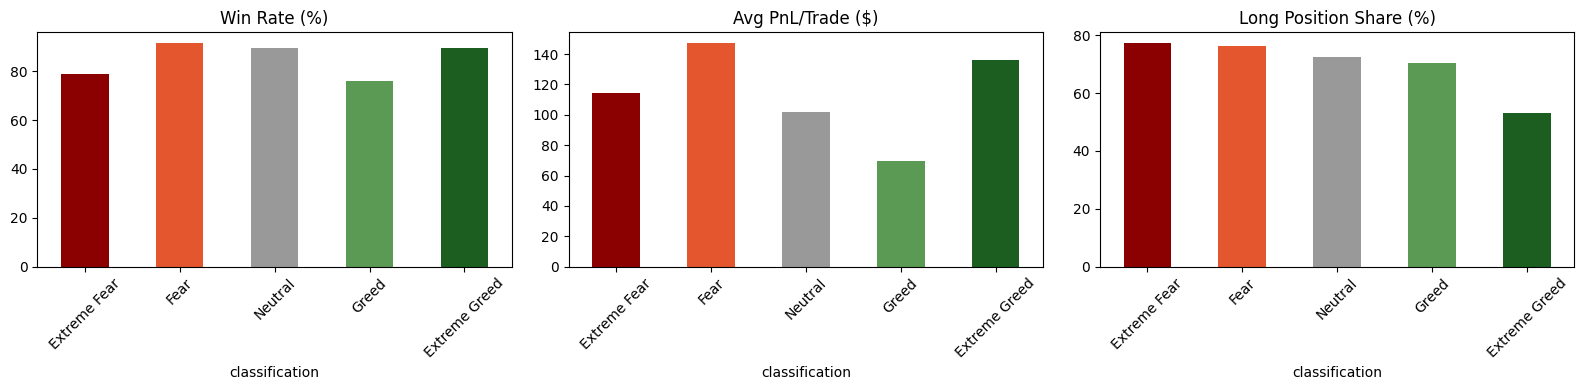

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16,4))
colors = ['#8B0000','#E4572E','#999999','#5B9A54','#1B5E20']

summary['win_rate'].plot(kind='bar', ax=axes[0], color=colors, title='Win Rate (%)')
summary['avg_pnl'].plot(kind='bar', ax=axes[1], color=colors, title='Avg PnL/Trade ($)')
bias['long_pct'].plot(kind='bar', ax=axes[2], color=colors, title='Long Position Share (%)')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Summary: I merged more than 211,000 Hyperliquid trades with the daily Fear & Greed Index to analyze whether market sentiment is related to trader performance. The analysis shows that traders achieved the highest win rate and average profit during Fear, while the lowest performance occurred during Greed, indicating that the relationship between sentiment and trading success is not a simple progression from fear to greed. Traders in this dataset also opened more long positions during Fear (76.2%) than during Greed (70.6%), suggesting a contrarian trading style rather than a momentum-based approach. Segmenting by account shows 20 of 22 accounts are consistently profitable overall, while a smaller group experiences significant performance swings depending on market sentiment. This suggests that market sentiment is not a universal trading edge but has a greater impact on some traders than others. A practical strategy takeaway is to increase position sizes during Fear and reduce exposure during Greed.